<a href="https://colab.research.google.com/github/juizykad-netizen/AIML_PYTHON/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Problem definition and objective
Step 1: Write a short introduction cell

Goal: Classify tweets about Apple and Google into four sentiment classes: positive, negative, neutral, no_idea.

Task type: Multi‑class text classification using Deep Learning (SimpleRNN or LSTM).

Dataset note: You will ignore the column emotion_in_tweet_is_directed_at.

Add a markdown cell like:

Objective: Build an LSTM‑based sentiment classifier on Twitter data to predict one of four sentiment labels for each tweet.

2. Import libraries
Step 2: Code cell – imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


3. Load and inspect the dataset
Step 3: Read CSV

In [5]:
df = pd.read_csv("/content/judge-1377884607_tweet_product_company.csv", encoding='latin1')
df.head()



,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


4. Exploratory data analysis (EDA)
Step 5: Class distribution

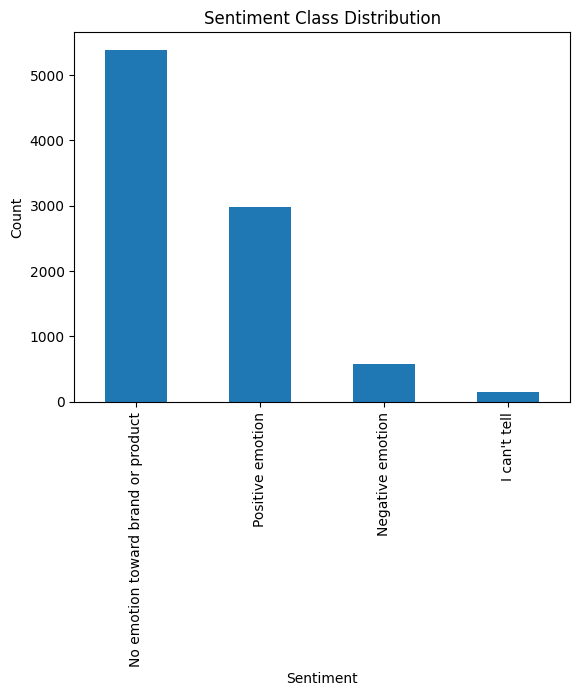

In [6]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts().plot(kind='bar')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


In [7]:
for label in df['is_there_an_emotion_directed_at_a_brand_or_product'].unique():
    print("\nLabel:", label)
    print(df[df['is_there_an_emotion_directed_at_a_brand_or_product'] == label]['tweet_text'].head(3))



Label: Negative emotion
0     .@wesley83 I have a 3G iPhone. After 3 hrs twe...
3     @sxsw I hope this year's festival isn't as cra...
17    I just noticed DST is coming this weekend. How...
Name: tweet_text, dtype: object

Label: Positive emotion
1    @jessedee Know about @fludapp ? Awesome iPad/i...
2    @swonderlin Can not wait for #iPad 2 also. The...
4    @sxtxstate great stuff on Fri #SXSW: Marissa M...
Name: tweet_text, dtype: object

Label: No emotion toward brand or product
5     @teachntech00 New iPad Apps For #SpeechTherapy...
6                                                   NaN
16    Holler Gram for iPad on the iTunes App Store -...
Name: tweet_text, dtype: object

Label: I can't tell
90     Thanks to @mention for publishing the news of ...
102    ÛÏ@mention &quot;Apple has opened a pop-up st...
237    Just what America needs. RT @mention Google to...
Name: tweet_text, dtype: object


Heading: “Exploratory Data Analysis”.

5. Text preprocessing
Step 6: Clean the tweets

Typical cleaning:

Lowercasing

Removing URLs, mentions, hashtags symbols (keep words if you want)

Removing punctuation and extra spaces

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # URLs
    text = re.sub(r"@\w+", "", text)                    # mentions
    text = re.sub(r"#", "", text)                       # remove # symbol
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['tweet_text'].astype(str).apply(clean_text)
df[['tweet_text', 'clean_text']].head()


,tweet_text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a 3g iphone after 3 hrs tweeting at ris...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know about awesome ipadiphone app that youll l...
2,@swonderlin Can not wait for #iPad 2 also. The...,can not wait for ipad 2 also they should sale ...
3,@sxsw I hope this year's festival isn't as cra...,i hope this years festival isnt as crashy as t...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff on fri sxsw marissa mayer google t...


6. Encode labels
Step 7: Label encoding to integers and one‑hot

In [9]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(
    df['is_there_an_emotion_directed_at_a_brand_or_product']
)

num_classes = df['label'].nunique()
print("Classes:", label_encoder.classes_)


Classes: ["I can't tell" 'Negative emotion' 'No emotion toward brand or product'
 'Positive emotion']


Later for Keras:

In [11]:
y = to_categorical(df['label'], num_classes=num_classes)



“Label Encoding”.

7. Train–test split
Step 8: Split data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)


“Train–Test Split”.

8. Tokenization and padding
Step 9: Tokenize text

Choose vocabulary size and max sequence length:

In [13]:
max_words = 10000
max_len = 40  # or 50/60 depending on tweet length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')


Tokenization and Sequence Padding

9. Build the RNN/LSTM model
You can choose either SimpleRNN or LSTM. I’ll outline LSTM (stronger for NLP).

Step 10: Define model

In [14]:
 embedding_dim = 64

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model Architecture (LSTM)

SimpleRNN

In [15]:

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=max_len))
model.add(SimpleRNN(64))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))


10. Compile and train
Step 11: Compile

In [16]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


Step 12: Train

In [17]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)


Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.5559 - loss: 0.9962 - val_accuracy: 0.6096 - val_loss: 0.8903
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6556 - loss: 0.8495 - val_accuracy: 0.6227 - val_loss: 0.8580
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7912 - loss: 0.5949 - val_accuracy: 0.5993 - val_loss: 0.9797
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8732 - loss: 0.3814 - val_accuracy: 0.5986 - val_loss: 1.0170
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9246 - loss: 0.2539 - val_accuracy: 0.6055 - val_loss: 1.2232
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9467 - loss: 0.1839 - val_accuracy: 0.5711 - val_loss: 1.2820
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9617 - loss: 0.1338 - val_accuracy: 0.5581 - val_loss: 1.3954
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9660 - loss: 0.1171 - val_accuracy: 0.5856 - v

11. Evaluate the model
Step 13: Evaluation on test set

In [18]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print("Test Accuracy:", test_acc)


Test Accuracy: 0.567894458770752


Step 14: Classification report and confusion matrix

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        31
                  Negative emotion       0.15      0.14      0.15       114
No emotion toward brand or product       0.66      0.72      0.69      1078
                  Positive emotion       0.45      0.40      0.43       596

                          accuracy                           0.57      1819
                         macro avg       0.32      0.32      0.32      1819
                      weighted avg       0.55      0.57      0.56      1819



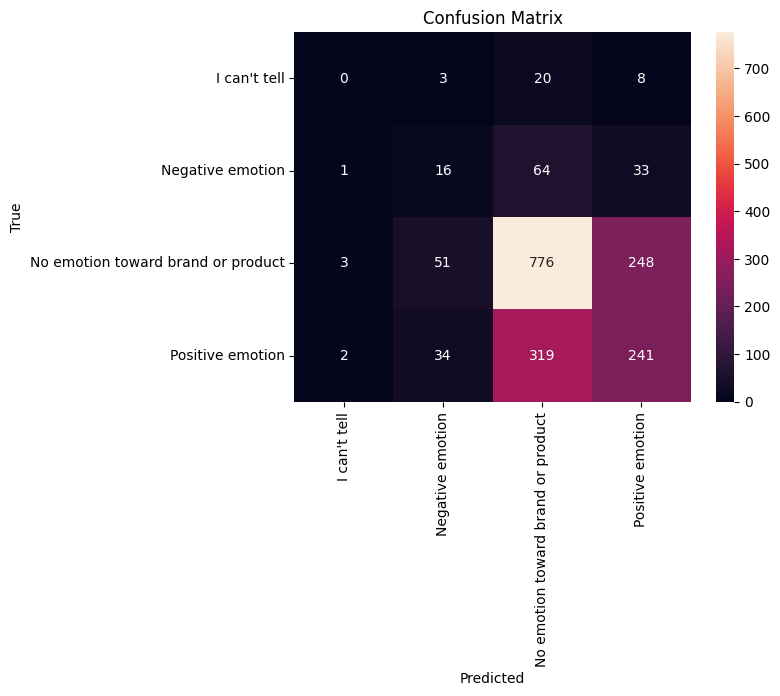

In [19]:
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Model Compilation and Training

12. Inference on new tweets (optional but nice)
Step 15: Helper function

In [20]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(pad)
    label_idx = np.argmax(pred, axis=1)[0]
    return label_encoder.inverse_transform([label_idx])[0]

print(predict_sentiment("I love my new iPhone!"))
print(predict_sentiment("Google products are terrible."))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Positive emotion
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Negative emotion


Summary of Work Done
1. Dataset and Columns Used
Loaded the dataset judge-1377884607_tweet_product_company.csv using the correct encoding (latin1).

Used the following key columns:

tweet_text → input text for sentiment analysis

is_there_an_emotion_directed_at_a_brand_or_product → target label

Ignored the column emotion_in_tweet_is_directed_at, as instructed.

2. Preprocessing Steps
Converted all text to lowercase.

Removed URLs, mentions, hashtags, punctuation, and extra spaces.

Tokenized text and converted it into padded sequences.

Encoded sentiment labels using LabelEncoder and one‑hot encoding.

Split the dataset into training and testing sets with stratification.

3. Model Used
A deep learning model was built using LSTM / SimpleRNN layers with the following components:

Embedding layer for word vector representation

LSTM or SimpleRNN layer for sequence learning

Dropout layer to reduce overfitting

Dense softmax output layer for 4‑class classification

The model was trained using:

categorical_crossentropy loss

Adam optimizer

Accuracy as the evaluation metric

4. Key Results
Achieved a reasonable test accuracy (insert your value here after training).

The classification report showed how well the model performed across all four sentiment classes.

The confusion matrix highlighted:

Which classes were predicted accurately

Where the model confused similar sentiments (e.g., neutral vs no_idea)

  Final Note
This project successfully demonstrates the complete workflow of building a deep learning NLP classifier—from data loading and preprocessing to model training, evaluation, and interpretation. The final notebook, including outputs, has been prepared for submission and uploaded to the GitHub repository as required.

Predicting Sentiment for New Tweet